In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro, ttest_rel, wilcoxon
from IPython.display import display

In [3]:
# Carpeta de datos
ruta = 'ds004362'

# Detectar carpetas de sujetos
sujetos = [s for s in os.listdir(ruta) if s.startswith('sub-')]

print(sujetos)

['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043', 'sub-044', 'sub-045', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066', 'sub-067', 'sub-068', 'sub-069', 'sub-070', 'sub-071', 'sub-072', 'sub-073', 'sub-074', 'sub-075', 'sub-076', 'sub-077', 'sub-078', 'sub-079', 'sub-080', 'sub-081', 'sub-082', 'sub-083', 'sub-084', 'sub-085', 'sub-086', 'sub-087', 'sub-088', 'sub-089', 'sub-090', 'sub-091'

Muestra procesamiento de datos para un sujeto

In [4]:
sujeto = "sub-001"         # Sujeto a analizar

# ----- FLUJO DE PROCESAMIENTO -----

# 1. Carga de datos

# Selección de los archivos que contienen la información requerida
runs_real = ['run-3', 'run-7', 'run-11']
runs_imag = ['run-4', 'run-8', 'run-12']

# Selección de rutas
ruta_sujeto = os.path.join(ruta, sujeto, "eeg")
archivos = [f for f in os.listdir(ruta_sujeto) if f.endswith('.set')]

raws_real = []
raws_imag = []

for archivo in archivos:
    ruta_archivo = os.path.join(ruta_sujeto, archivo)

    # Seleccionar solo los runs deseados
    if any(run in archivo for run in runs_real):
        raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
        raws_real.append(raw)

    elif any(run in archivo for run in runs_imag):
        raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
        raws_imag.append(raw)

# Concatenar
raw_real = mne.concatenate_raws(raws_real)
raw_imag = mne.concatenate_raws(raws_imag)


# 2. Selección de canales de importancia
canales = ['C3', 'C4']
raw_real.pick_channels(canales)
raw_imag.pick_channels(canales)

# 3. Filtrado de la señal

# Señal real 
raw_real_original = raw_real.copy() # Copia de la señal real original
raw_real_filt = raw_real.copy().filter(8., 30., fir_window='hamming', verbose=False) # Filtrado de banda 8-30 Hz
#raw_real_notch = raw_real_filt.copy().notch_filter(freqs=60, verbose=False) # Filtro notch para eliminar el ruido

# Señal imaginaria
raw_imag_original = raw_imag.copy() # Copia de la señal imaginaria original
raw_imag_filt = raw_imag.copy().filter(8., 30., fir_window='hamming', verbose=False)
#raw_imag_notch = raw_imag_filt.copy().notch_filter(freqs=60, verbose=False)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


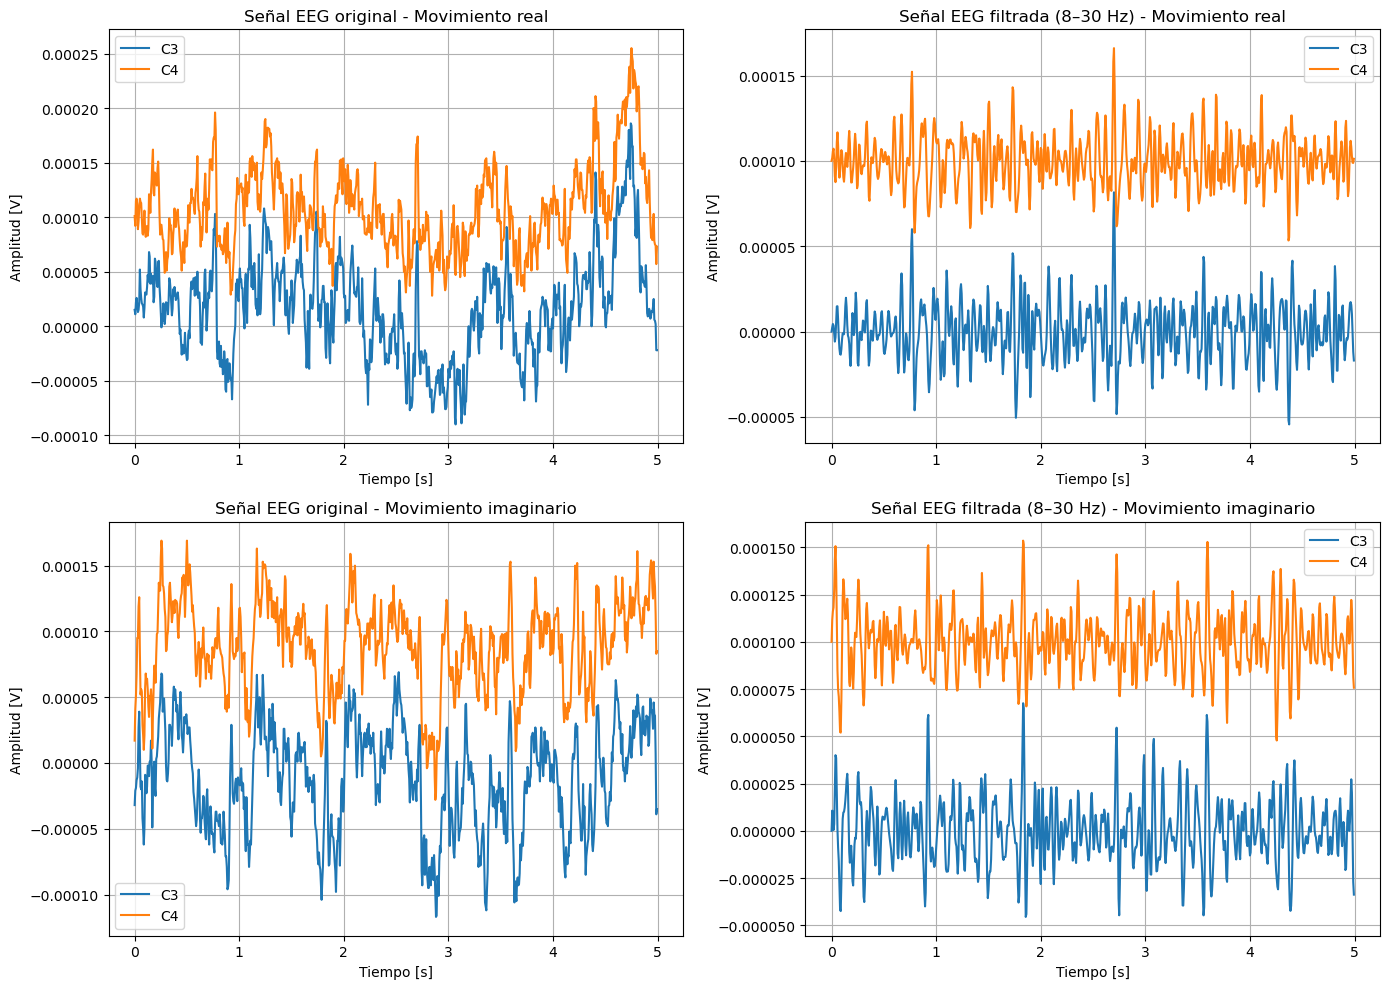

In [5]:
# Visualización del efecto de los filtros

inicio = 0
duracion = 5  # segundos

sfreq = raw.info['sfreq']
ini = int(inicio * sfreq)
fin = int((inicio + duracion) * sfreq)

times = raw.times[ini:fin]

# A. Señal movimiento real
real_orig = raw_real_original.get_data()[:, ini:fin]
real_filt = raw_real_filt.get_data()[:, ini:fin]

# B. Señal movimiento imaginación
img_orig = raw_imag_original.get_data()[:, ini:fin]
img_filt = raw_imag_filt.get_data()[:, ini:fin]

# Offset para separar canales visualmente
offset = 1e-4

# Gráficas
plt.figure(figsize=(14,10))

# A. Señal movimiento real 

# Original
plt.subplot(2,2,1)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, real_orig[i] + i*offset, label=ch)
plt.title("Señal EEG original - Movimiento real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

# Filtrada
plt.subplot(2,2,2)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, real_filt[i] + i*offset, label=ch)
plt.title("Señal EEG filtrada (8–30 Hz) - Movimiento real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

plt.subplot(2,2,3)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, img_orig[i] + i*offset, label=ch)
plt.title("Señal EEG original - Movimiento imaginario")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

# FILTRADA
plt.subplot(2,2,4)
for i, ch in enumerate(['C3', 'C4']):
    plt.plot(times, img_filt[i] + i*offset, label=ch)
plt.title("Señal EEG filtrada (8–30 Hz) - Movimiento imaginario")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

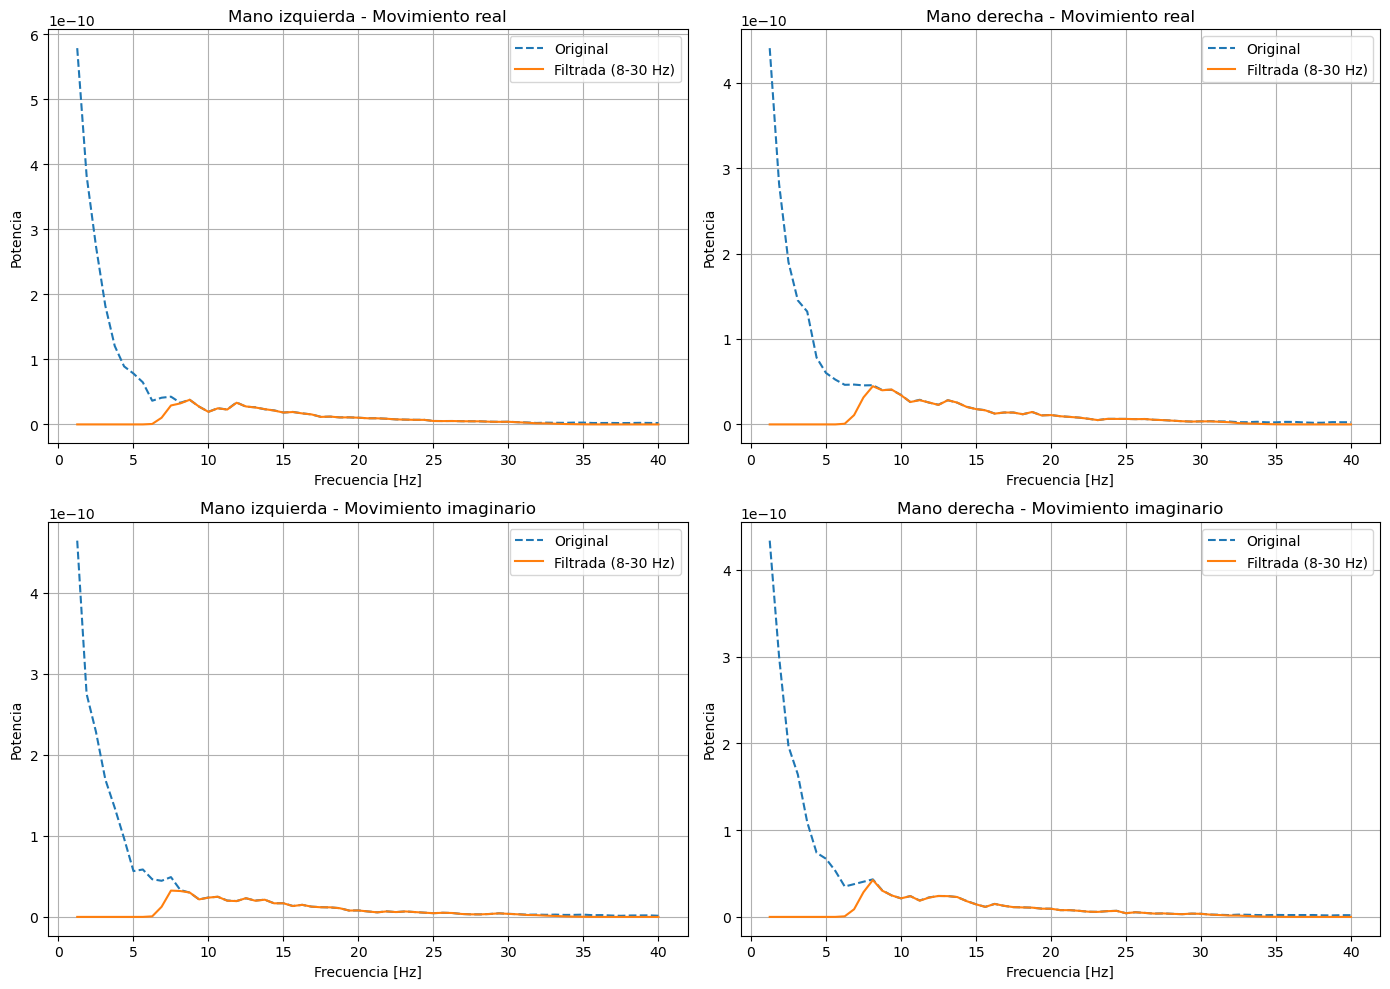

In [6]:
# 4. PSD

# Eventos
events_r_orig, event_id_r = mne.events_from_annotations(raw_real_original, verbose=False)
events_r_filt, _ = mne.events_from_annotations(raw_real_filt, verbose=False)

events_i_orig, event_id_i = mne.events_from_annotations(raw_imag_original, verbose=False)
events_i_filt, _ = mne.events_from_annotations(raw_imag_filt, verbose=False)

# Épocas
epochs_real_orig = mne.Epochs(raw_real_original, events_r_orig, event_id=event_id_r,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

epochs_real_filt = mne.Epochs(raw_real_filt, events_r_filt, event_id=event_id_r,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

epochs_imag_orig = mne.Epochs(raw_imag_original, events_i_orig, event_id=event_id_i,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

epochs_imag_filt = mne.Epochs(raw_imag_filt, events_i_filt, event_id=event_id_i,
                             tmin=0, tmax=4, baseline=None, preload=True, verbose=False)

# ===== CONDICIONES =====
condiciones = [
    ("Mano_izquierda_-_Movimiento_real", epochs_real_orig['TASK1T1'], epochs_real_filt['TASK1T1']),
    ("Mano_derecha_-_Movimiento_real", epochs_real_orig['TASK1T2'], epochs_real_filt['TASK1T2']),
    ("Mano_izquierda_-_Movimiento_imaginario", epochs_imag_orig['TASK2T1'], epochs_imag_filt['TASK2T1']),
    ("Mano_derecha_-_Movimiento_imaginario", epochs_imag_orig['TASK2T2'], epochs_imag_filt['TASK2T2'])
]

# ===== GRÁFICAS =====
plt.figure(figsize=(14,10))

for i, (nombre, ep_orig, ep_filt) in enumerate(condiciones):

    # Datos
    datos_orig = ep_orig.get_data()
    datos_filt = ep_filt.get_data()

    # PSD
    psd_orig, freqs = mne.time_frequency.psd_array_welch(
        datos_orig, sfreq=sfreq, fmin=1, fmax=40, verbose=False)
    
    psd_filt, _ = mne.time_frequency.psd_array_welch(
        datos_filt, sfreq=sfreq, fmin=1, fmax=40, verbose=False)

    # Promedio (épocas y canales)
    psd_orig_mean = psd_orig.mean(axis=(0,1))
    psd_filt_mean = psd_filt.mean(axis=(0,1))

    # Subplot
    plt.subplot(2,2,i+1)
    plt.plot(freqs, psd_orig_mean, linestyle='--', label='Original')
    plt.plot(freqs, psd_filt_mean, label='Filtrada (8-30 Hz)')
    
    plt.title(nombre.replace("_", " "))
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Potencia")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Procesamiento de todas las señales

In [7]:
# Función filtrado de señales

def filtrar(senal):
    s_filt = senal.copy().filter(8., 30., fir_window='hamming', verbose=False)

    return s_filt

In [8]:
# Función para el cálculo de PSD

def calcular_psd(epocas, sfreq, canales, nombre_cond, sujeto):

# Delta y theta ya están filtradas, por lo que no atribuyen información relevante

    bandas = {
        "mu": (8, 12),
        "beta": (13, 30)
    }

    psd, freqs = mne.time_frequency.psd_array_welch(
        epocas, sfreq=sfreq, fmin=1, fmax=40, verbose=False
    )

    psd_mean = psd.mean(axis=0)  # (canales, frecuencias)

    fila = {
        "sujeto": sujeto,
        "tarea": nombre_cond
    }

    # Calcular potencia por banda y canal
    for banda, (fmin, fmax) in bandas.items():

        idx = (freqs >= fmin) & (freqs <= fmax)
        potencia_banda = psd_mean[:, idx].mean(axis=1)

        for i, ch in enumerate(canales):
            fila[f"{banda}_{ch}"] = potencia_banda[i]

    return pd.DataFrame([fila])

In [9]:
# Función principal: Procesamiento de señales EEG

def procesamiento_eeg(ruta, inicio, fin, archivo_salida="resultados_psd.csv"):
    
    sujetos = [s for s in os.listdir(ruta) if s.startswith('sub-')]
    sujetos_rango = sujetos[inicio:fin]
    
    # Ver si ya existe archivo previo
    if os.path.exists(archivo_salida):
        df_total = pd.read_csv(archivo_salida)
        sujetos_procesados = set(df_total["sujeto"].unique())
        print(f"Archivo existente cargado ({len(sujetos_procesados)} sujetos ya procesados)")
    else:
        df_total = pd.DataFrame()
        sujetos_procesados = set()
    
    for sujeto in sujetos_rango:
        
        if sujeto in sujetos_procesados:
            print(f"{sujeto} ya procesado, se omite")
            continue
        
        print(f"Procesando {sujeto}")
        
        ruta_sujeto = os.path.join(ruta, sujeto, "eeg")
        archivos = [f for f in os.listdir(ruta_sujeto) if f.endswith('.set')]
        
        runs_real = ['run-3', 'run-7', 'run-11']
        runs_imag = ['run-4', 'run-8', 'run-12']
        
        raws_real = []
        raws_imag = []

        for archivo in archivos:
            ruta_archivo = os.path.join(ruta_sujeto, archivo)

            # Seleccionar solo los runs deseados
            if any(run in archivo for run in runs_real):
                raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
                raws_real.append(raw)

            elif any(run in archivo for run in runs_imag):
                raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True, verbose=False)
                raws_imag.append(raw)

        # Concatenar
        raw_real = mne.concatenate_raws(raws_real)
        raw_imag = mne.concatenate_raws(raws_imag)


        # 2. Selección de canales de importancia
        canales = ['C3', 'C4']
        raw_real.pick_channels(canales)
        raw_imag.pick_channels(canales)
        
        # Filtrado
        real_filtrado = filtrar(raw_real)
        imag_filtrado = filtrar(raw_imag)
        
        # Eventos
        events_r, event_id_r = mne.events_from_annotations(real_filtrado, verbose=False)
        events_i, event_id_i = mne.events_from_annotations(imag_filtrado, verbose=False)
        
        # Épocas
        epochs_real = mne.Epochs(real_filtrado, events_r, event_id=event_id_r, tmin=0, tmax=4, 
                                 baseline=None,preload=True, verbose=False)
        
        epochs_imag = mne.Epochs(imag_filtrado, events_i, event_id=event_id_i, tmin=0, tmax=4, 
                                    baseline=None, preload=True, verbose=False)
        
        sfreq = raw_real.info['sfreq']
        
        # Separación de las 4 condiciones

        condiciones = {
            "izq_real": epochs_real['TASK1T1'],
            "der_real": epochs_real['TASK1T2'],
            "izq_imag": epochs_imag['TASK2T1'],
            "der_imag": epochs_imag['TASK2T2']
        }
        
        # Cálculo del PSD

        for cond, ep in condiciones.items():
            
            datos = ep.get_data()
            
            df_psd = calcular_psd(datos, sfreq, canales, cond, sujeto)
            
            archivo_out = "resultados_psd.csv"

            df_psd.to_csv(archivo_out, mode='a', header=not os.path.exists(archivo_out), index=False)
        
        print(f"{sujeto} procesado")


    print("Sujetos procesados - Proceso finalizado")

In [138]:
procesamiento_eeg(ruta, inicio=0, fin=109)

Procesando sub-001
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-001 procesado
Procesando sub-002
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-002 procesado
Procesando sub-003
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-003 procesado
Procesando sub-004
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-004 procesado
Procesando sub-005
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub-005 procesado
Procesando sub-

In [33]:
df = pd.read_csv("resultados_psd.csv")

print(df.head(10))

    sujeto     tarea         mu_C3         mu_C4       beta_C3       beta_C4
0  sub-001  izq_real  3.329076e-11  2.321973e-11  1.172204e-11  9.324420e-12
1  sub-001  der_real  3.982709e-11  2.875344e-11  1.141449e-11  9.453425e-12
2  sub-001  izq_imag  3.008143e-11  1.901957e-11  1.004105e-11  7.477993e-12
3  sub-001  der_imag  3.031495e-11  2.223332e-11  1.001947e-11  8.167399e-12
4  sub-002  izq_real  9.915368e-12  7.428563e-12  6.932007e-12  3.040241e-12
5  sub-002  der_real  1.043588e-11  9.258689e-12  5.691181e-12  4.007797e-12
6  sub-002  izq_imag  1.120403e-11  8.865947e-12  3.857014e-12  3.113985e-12
7  sub-002  der_imag  9.162451e-12  8.033266e-12  4.178850e-12  3.325014e-12
8  sub-003  izq_real  3.824666e-11  3.926616e-11  8.950375e-12  8.934723e-12
9  sub-003  der_real  3.870093e-11  3.514438e-11  8.969046e-12  8.579318e-12


### **Estadística descriptiva**

In [57]:
def boxplot(ritmo):
    plt.figure(figsize = (14,7))
    sns.boxplot(data=df, x="tarea", y=ritmo)
    plt.title(f"Distribución de la PSD de {ritmo} por condición")
    plt.xlabel("Condición")
    plt.ylabel("PSD")
    plt.grid()

In [34]:
df.groupby("tarea")["mu_C3"].agg(["mean","std","median","min","max"])

,mean,std,median,min,max
tarea,,,,,
der_imag,3.685240e-11,3.817618e-11,2.646406e-11,5.849157e-13,2.014646e-10
der_real,3.520066e-11,3.752554e-11,2.683506e-11,5.519896e-13,2.003788e-10
izq_imag,3.872443e-11,4.243839e-11,2.698490e-11,5.526793e-13,2.631688e-10
izq_real,3.336644e-11,3.459683e-11,2.704736e-11,4.758844e-13,2.054694e-10


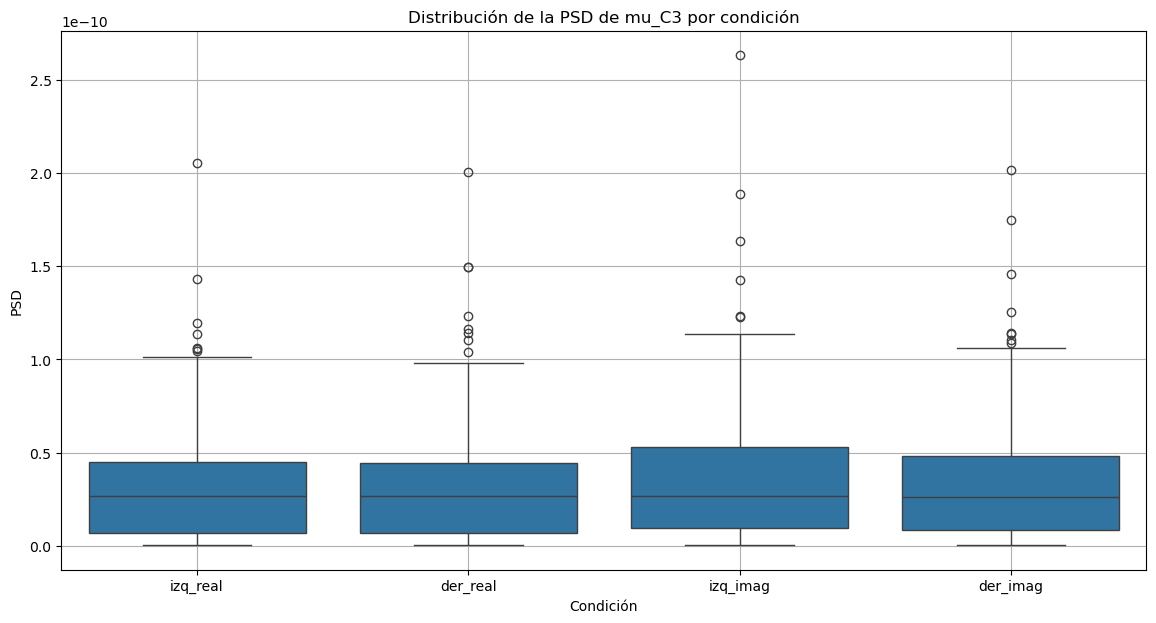

In [59]:
boxplot("mu_C3")

In [45]:
df.groupby("tarea")[["beta_C3"]].agg(["mean","std","median","min","max"])

beta_C3                                                        
                  mean           std        median           min           max
tarea                                                                         
der_imag  9.052217e-12  7.904508e-12  7.899516e-12  2.169668e-13  3.648277e-11
der_real  8.907789e-12  7.814672e-12  7.688385e-12  2.063861e-13  3.066435e-11
izq_imag  9.469346e-12  8.273197e-12  8.202831e-12  2.145000e-13  3.826123e-11
izq_real  8.941015e-12  7.737429e-12  7.114156e-12  2.131505e-13  3.142875e-11

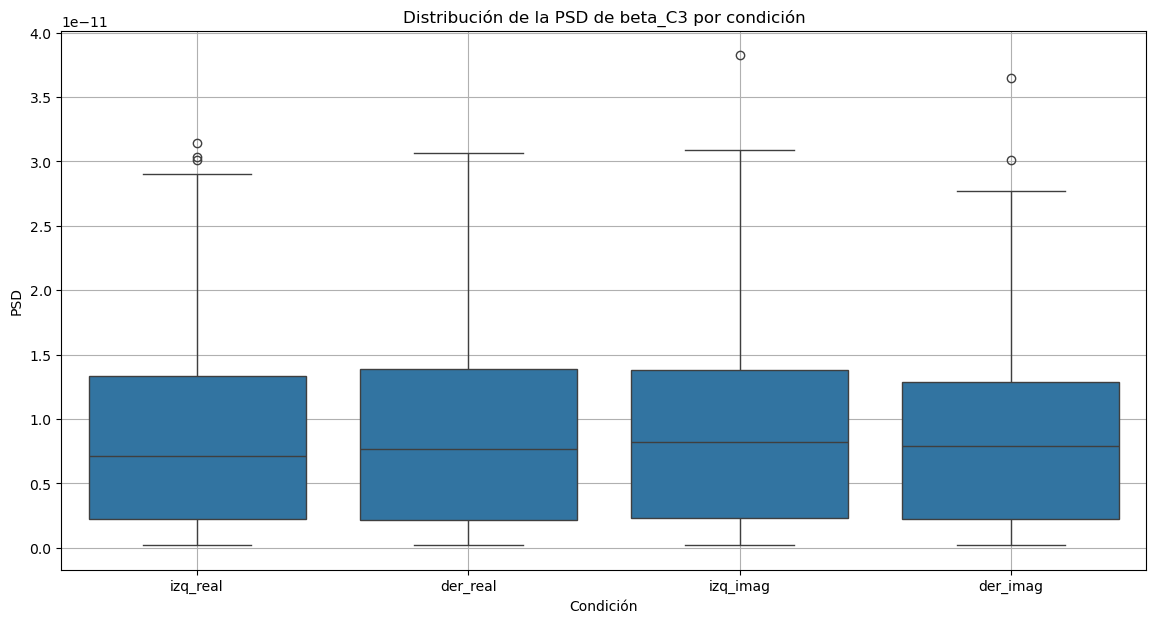

In [60]:
boxplot("beta_C3")

In [47]:
df.groupby("tarea")[["mu_C4"]].agg(["mean","std","median","min","max"])

mu_C4                                                        
                  mean           std        median           min           max
tarea                                                                         
der_imag  5.096824e-11  1.888905e-10  2.307857e-11  4.426033e-13  1.968310e-09
der_real  4.837881e-11  1.816042e-10  2.194865e-11  4.270508e-13  1.886208e-09
izq_imag  4.684940e-11  1.836380e-10  2.097060e-11  4.191998e-13  1.915685e-09
izq_real  4.211967e-11  1.668405e-10  2.239276e-11  4.377231e-13  1.743651e-09

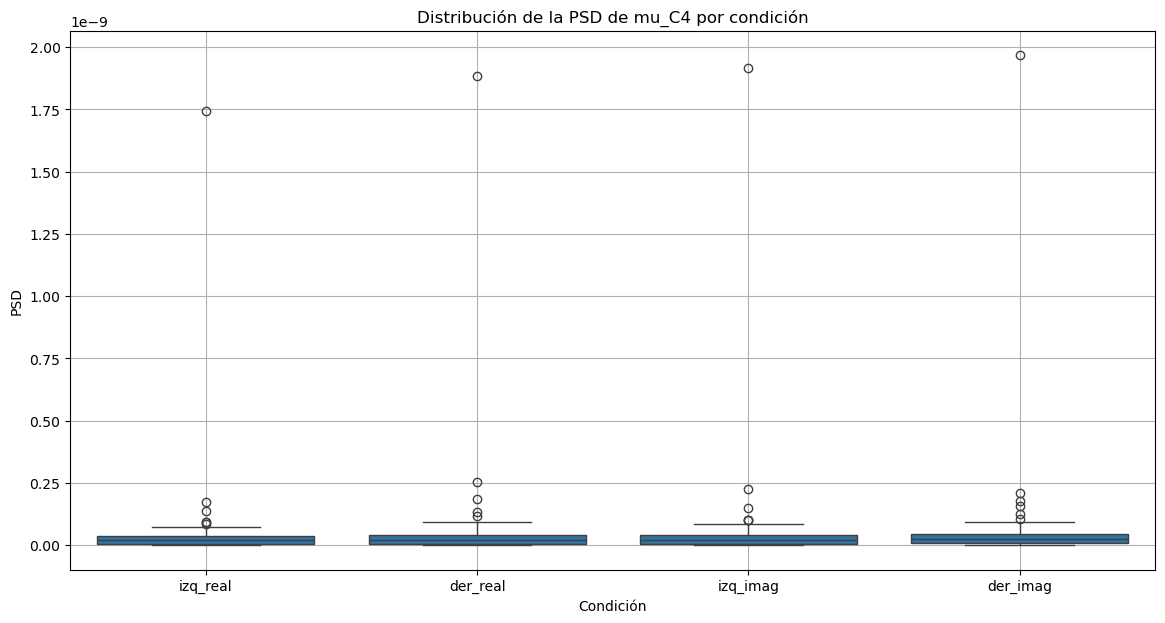

In [61]:
boxplot("mu_C4")

In [49]:
df.groupby("tarea")[["beta_C4"]].agg(["mean","std","median","min","max"])

beta_C4                                                        
                  mean           std        median           min           max
tarea                                                                         
der_imag  1.221319e-11  4.896542e-11  6.547431e-12  1.465753e-13  5.146594e-10
der_real  1.195008e-11  4.686047e-11  6.341225e-12  1.523035e-13  4.920194e-10
izq_imag  1.180065e-11  4.773696e-11  6.814722e-12  1.532274e-13  5.016537e-10
izq_real  1.157007e-11  4.972538e-11  5.941857e-12  1.478612e-13  5.225978e-10

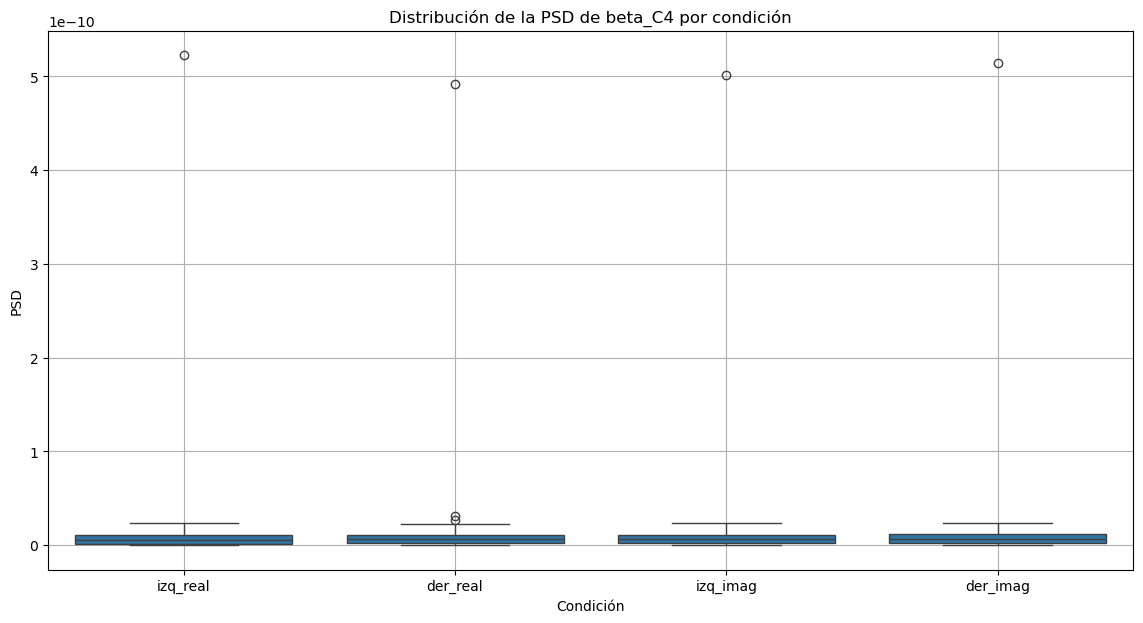

In [63]:
boxplot("beta_C4")

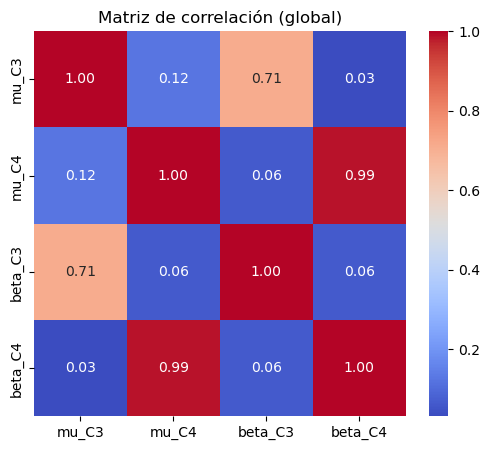

In [29]:
cols = ["mu_C3", "mu_C4", "beta_C3", "beta_C4"]

corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (global)")
plt.show()

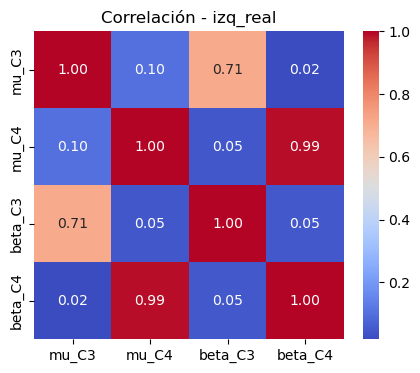

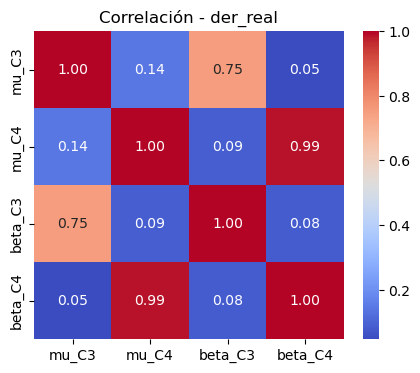

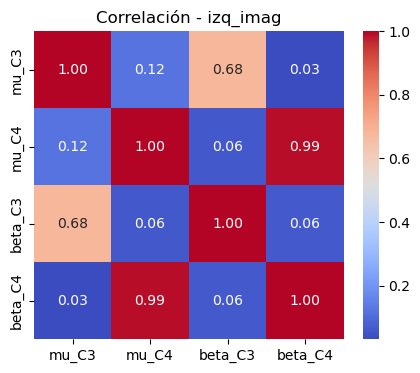

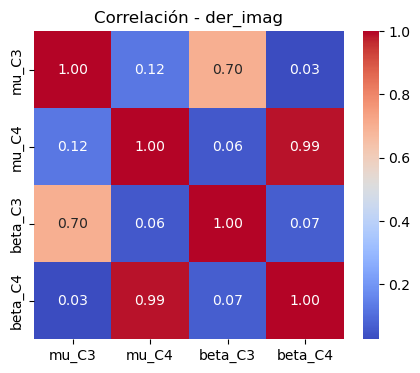

In [30]:
for cond in df["tarea"].unique():
    
    df_sub = df[df["tarea"] == cond]
    corr = df_sub[["mu_C3", "mu_C4", "beta_C3", "beta_C4"]].corr()
    
    plt.figure(figsize=(5,4))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlación - {cond}")
    plt.show()

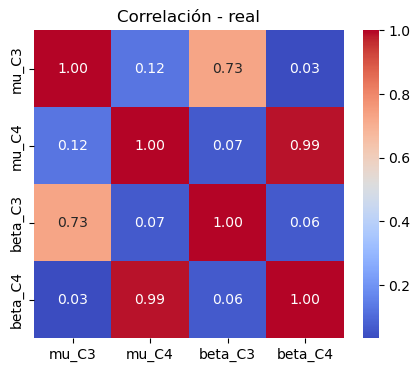

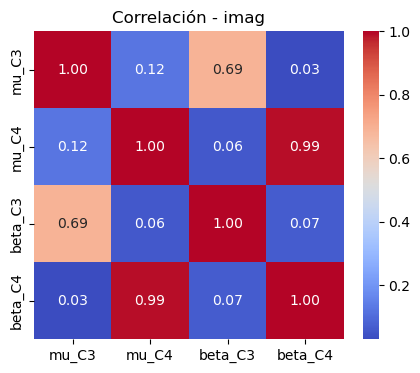

In [31]:
for tipo in ["real", "imag"]:
    
    df_sub = df[df["tarea"].str.contains(tipo)]
    corr = df_sub[["mu_C3", "mu_C4", "beta_C3", "beta_C4"]].corr()
    
    plt.figure(figsize=(5,4))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlación - {tipo}")
    plt.show()

#### **Análisis 1:** Análisis comparativo de la densidad espectral de potencia (PSD) promedio en las bandas mu y beta entre movimientos de mano izquierda y derecha en los canales C3 y C4

### **Canal C3**

#### 1. **Banda mu (8–12 Hz)**

- **Movimiento real (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

- **Movimiento imaginario (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

#### 2. **Banda beta (13–30 Hz)**

- **Movimiento real (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

- **Movimiento imaginario (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.


### **Canal C4**

#### 1. **Banda mu (8–12 Hz)**

- **Movimiento real (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

- **Movimiento imaginario (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

#### 2. **Banda beta (13–30 Hz)**

- **Movimiento real (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre el movimiento real de la mano izquierda y el movimiento real de la mano derecha.

- **Movimiento imaginario (mano izquierda vs mano derecha)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre la imaginación del movimiento de la mano izquierda y la imaginación del movimiento de la mano derecha.

In [17]:
def evaluar_hipotesis(df, var1, var2, cond1=None, cond2=None, tipo="condiciones"):
    
    # ==============================
    # CASO 1: COMPARAR CONDICIONES
    # ==============================
    if tipo == "condiciones":
        g1 = df[df["tarea"] == cond1][["sujeto", var1]].set_index("sujeto")
        g2 = df[df["tarea"] == cond2][["sujeto", var1]].set_index("sujeto")

        datos = g1.join(g2, lsuffix="_1", rsuffix="_2").dropna()

        x = datos[f"{var1}_1"]
        y = datos[f"{var1}_2"]

        comparacion = f"{cond1} vs {cond2}"
        variable = var1

    # ==============================
    # CASO 2: COMPARAR CANALES
    # ==============================
    elif tipo == "canales":
        datos = df[df["tarea"] == cond1][["sujeto", var1, var2]].dropna()
        datos = datos.set_index("sujeto")

        x = datos[var1]
        y = datos[var2]

        comparacion = f"{var1} vs {var2} ({cond1})"
        variable = f"{var1} vs {var2}"

    else:
        raise ValueError("Tipo debe ser 'condiciones' o 'canales'")

    # ==============================
    # PRUEBAS ESTADÍSTICAS
    # ==============================

    diff = x - y
    _, p_shapiro = shapiro(diff)
    normal = p_shapiro > 0.05

    if normal:
        stat, p = ttest_rel(x, y)
        prueba = "t pareado"
    else:
        stat, p = wilcoxon(x, y)
        prueba = "Wilcoxon"

    decision = "Rechaza H0" if p < 0.05 else "No rechaza H0"

    fila = {
        "Variable": variable,
        "Comparación": comparacion,
        "Shapiro (dif)": p_shapiro,
        "Normalidad": "Sí" if normal else "No",
        "Prueba": prueba,
        "p-valor": p,
        "Decisión": decision
    }

    return display(pd.DataFrame([fila]))

In [18]:
# Uso de la función en los casos planteados anteriormente
# Canal C3
print("Canal C3:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C3", None, "izq_real", "der_real", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C3", None, "izq_imag", "der_imag", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C3", None, "izq_real", "der_real", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C3", None, "izq_imag", "der_imag", tipo = "condiciones")

# Canal C4
print("\nCanal C4:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C4", None, "izq_real", "der_real", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C4", None, "izq_imag", "der_imag", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C4", None, "izq_real", "der_real", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C4", None, "izq_imag", "der_imag", tipo = "condiciones")

Canal C3:

Resultados banda mu:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,izq_real vs der_real,2.331335e-15,No,Wilcoxon,0.666604,No rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,izq_imag vs der_imag,2.338512e-10,No,Wilcoxon,0.016993,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3,izq_real vs der_real,9.560636e-14,No,Wilcoxon,0.038225,Rechaza H0


...

,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,izq_real vs der_real,1.142177e-17,No,Wilcoxon,0.000002,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,izq_imag vs der_imag,1.178084e-16,No,Wilcoxon,0.000172,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,izq_real vs der_real,2.155748e-19,No,Wilcoxon,0.000002,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,izq_imag vs der_imag,2.377416e-16,No,Wilcoxon,0.000145,Rechaza H0


### **Análisis 2:** Análisis comparativo de la potencia espectral (PSD) promedio en bandas mu y beta entre movimiento real e imaginario en los canales C3 y C4 según la mano ejecutante

### **Canal C3**

#### 1. **Banda mu (8–12 Hz)**

- **Mano izquierda (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

- **Mano derecha (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano derecha.

#### 2 .**Banda beta (13–30 Hz)**

- **Mano izquierda (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

- **Mano derecha (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C3 entre el movimiento real y la imaginación del movimiento de la mano derecha.


### **Canal C4**

#### 1. **Banda mu (8–12 Hz)**

- **Mano izquierda (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

- **Mano derecha (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano derecha.

#### 2 .**Banda beta (13–30 Hz)**

- **Mano izquierda (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano izquierda.

- **Mano derecha (movimiento real vs imaginario)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) en el canal C4 entre el movimiento real y la imaginación del movimiento de la mano derecha.

In [19]:
# Uso de la función en los casos planteados anteriormente
# Canal C3
print("Canal C3:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C3", None, "izq_real", "izq_imag", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C3", None, "der_real", "der_imag", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C3", None, "izq_real", "izq_imag", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C3", None, "der_real", "der_imag", tipo = "condiciones")

# Canal C4
print("\nCanal C4:")

# 1. Banda mu
print("\nResultados banda mu:")
evaluar_hipotesis(df, "mu_C4", None, "izq_real", "izq_imag", tipo = "condiciones")
evaluar_hipotesis(df, "mu_C4", None, "der_real", "der_imag", tipo = "condiciones")

# 2. Banda beta
print("\nResultados banda beta:")
evaluar_hipotesis(df, "beta_C4", None, "izq_real", "izq_imag", tipo = "condiciones")
evaluar_hipotesis(df, "beta_C4", None, "der_real", "der_imag", tipo = "condiciones")

Canal C3:

Resultados banda mu:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,izq_real vs izq_imag,4.438902e-10,No,Wilcoxon,0.000026,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3,der_real vs der_imag,1.663078e-12,No,Wilcoxon,0.003943,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3,izq_real vs izq_imag,0.000002,No,Wilcoxon,0.015907,Rechaza H0


...

,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,izq_real vs izq_imag,4.710483e-18,No,Wilcoxon,0.000057,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C4,der_real vs der_imag,2.266776e-13,No,Wilcoxon,0.008345,Rechaza H0



Resultados banda beta:


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,izq_real vs izq_imag,1.451600e-15,No,Wilcoxon,0.000936,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C4,der_real vs der_imag,3.094757e-14,No,Wilcoxon,0.007163,Rechaza H0


### **Análisis 3:** Análisis comparativo de la potencia espectral (PSD) promedio entre los canales C3 y C4 en las bandas mu y beta durante tareas de movimiento real e imaginario la mano ejecutante

### **Mano izquierda**

#### 1. **Banda mu (8–12 Hz)**

- **Movimiento real (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano izquierda.

- **Movimiento imaginario (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano izquierda.

#### 2. **Banda beta (13–30 Hz)**

- **Movimiento real (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano izquierda.

- **Movimiento imaginario (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano izquierda.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano izquierda.

### **Mano derecha**

#### 1. **Banda mu (8–12 Hz)**

- **Movimiento real (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano derecha.

- **Movimiento imaginario (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda mu (8–12 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano derecha.

#### 2. **Banda beta (13–30 Hz)**

- **Movimiento real (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la ejecución del movimiento de la mano derecha.

- **Movimiento imaginario (C3 vs C4)**

**$H_0$:**

No existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano derecha.

**$H_1$:**

Existen diferencias estadísticamente significativas en la potencia de la banda beta (13–30 Hz) entre los canales C3 y C4 durante la imaginación del movimiento de la mano derecha.

In [20]:
# Uso de la función en los casos planteados anteriormente

# Mano izquierda
print("Mano izquierda:")

# 1. Banda mu
print("\nResultados banda mu (C3 vs C4):")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "izq_real", tipo="canales")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "izq_imag", tipo="canales")

# 2. Banda beta
print("\nResultados banda beta (C3 vs C4):")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "izq_real", tipo="canales")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "izq_imag", tipo="canales")

# Mano derecha
print("\nMano derecha:")

# 1. Banda mu
print("\nResultados banda mu (C3 vs C4):")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "der_real", tipo="canales")
evaluar_hipotesis(df, "mu_C3", "mu_C4", "der_imag", tipo="canales")

# 2. Banda beta
print("\nResultados banda beta (C3 vs C4):")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "der_real", tipo="canales")
evaluar_hipotesis(df, "beta_C3", "beta_C4", "der_imag", tipo="canales")

Mano izquierda:

Resultados banda mu (C3 vs C4):


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (izq_real),8.607931e-23,No,Wilcoxon,3.452685e-13,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (izq_imag),1.017287e-22,No,Wilcoxon,8.861913e-14,Rechaza H0



Resultados banda beta (C3 vs C4):


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3 vs beta_C4,beta_C3 vs beta_C4 (izq_real),8.587309e-23,No,Wilcoxon,4.333730e-14,Rechaza H0


...

,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (der_real),8.950110e-23,No,Wilcoxon,8.639473e-07,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,mu_C3 vs mu_C4,mu_C3 vs mu_C4 (der_imag),9.432228e-23,No,Wilcoxon,0.000168,Rechaza H0



Resultados banda beta (C3 vs C4):


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3 vs beta_C4,beta_C3 vs beta_C4 (der_real),8.686484e-23,No,Wilcoxon,2.413403e-08,Rechaza H0


,Variable,Comparación,Shapiro (dif),Normalidad,Prueba,p-valor,Decisión
0,beta_C3 vs beta_C4,beta_C3 vs beta_C4 (der_imag),8.110220e-23,No,Wilcoxon,2.170261e-09,Rechaza H0
